## The Winter Bottleneck Result Showcase
Preperation: Loading dataset

In [1]:
import pandas as pd

final_df = pd.read_csv("../results/final_data.csv")
print(final_df.shape)
print(final_df.columns.tolist())
final_df.head()

(180781, 17)
['station_id', 'hour', 'arrivals', 'departures', 'net_flow', 'lat', 'lon', 'municipality', 'total_docks', 'pressure_index', 'temperature_2m', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'hour_of_day', 'day_of_week']


,station_id,hour,arrivals,departures,net_flow,lat,lon,municipality,total_docks,pressure_index,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover,hour_of_day,day_of_week
0,A32000,2025-11-01 01:00:00,0.0,1.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,10.542999,0.0,0.0,24.823036,58.0,1,Saturday
1,A32000,2025-11-01 07:00:00,1.0,0.0,1.0,42.353391,-71.044571,Boston,15.0,0.066667,7.743000,0.0,0.0,26.109928,90.0,7,Saturday
2,A32000,2025-11-01 12:00:00,0.0,2.0,-2.0,42.353391,-71.044571,Boston,15.0,-0.133333,8.143000,0.0,0.0,21.996117,36.0,12,Saturday
3,A32000,2025-11-01 13:00:00,3.0,0.0,3.0,42.353391,-71.044571,Boston,15.0,0.200000,9.092999,0.0,0.0,21.589495,72.0,13,Saturday
4,A32000,2025-11-01 14:00:00,2.0,3.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,9.943000,0.0,0.0,22.442324,16.0,14,Saturday


### Section 1 - Hour of Day x Pressure Index Relationship
Here, data indicates which hours during the day has the highest pressure index as well as the % of stations that has pressure index above 0.2. This is to examine the peak hours in a day, setting the foundation for weather analysis.

In [2]:
from src.analyze import analyze_hourly_imbalance

hourly_imbalance = analyze_hourly_imbalance(final_df, severe_threshold=0.2)
hourly_imbalance.head()

,hour_of_day,mean_abs_pressure,severe_percent
0,0,0.070686,2.989324
1,1,0.072058,3.517588
2,2,0.067891,2.231147
3,3,0.061321,0.751880
4,4,0.057882,0.345722


#### Chart 1.1 - Mean Imbalance by Hour

The peak imbalance time of the day is at 8AM, with 5-6PM following as the second peak.
As shown in the graph, there are several hours that have severe imbalance. The hours are:
- 7AM - 9AM
- 3PM - 7PM

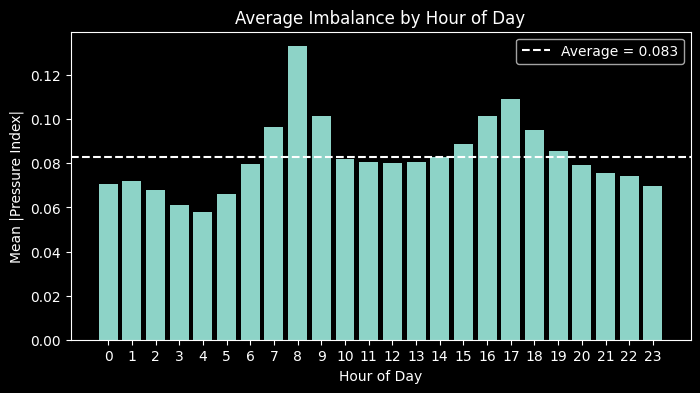

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    hourly_imbalance["hour_of_day"],
    hourly_imbalance["mean_abs_pressure"],
)

#Adding average line to showcase the peaks
avg_value = hourly_imbalance["mean_abs_pressure"].mean()

plt.axhline(
    y=avg_value,
    linestyle="--",
    label=f"Average = {avg_value:.3f}",
)

plt.xlabel("Hour of Day")
plt.ylabel("Mean |Pressure Index|")
plt.title("Average Imbalance by Hour of Day")

plt.xticks(range(24))
plt.legend()

plt.show()
plt.close()

#### Chart 1.2 - % of station that are severely imbalanced during the day
As shown in the graph, several hours shows high percentage of sever imbalanced stations count. The hours are:
- 7AM - 9AM
- 3PM - 7PM

The result are highly correlated with the average absolute pressure index and the % of the imbalanced station during these two period, thereby identifying these two period as the peak period.

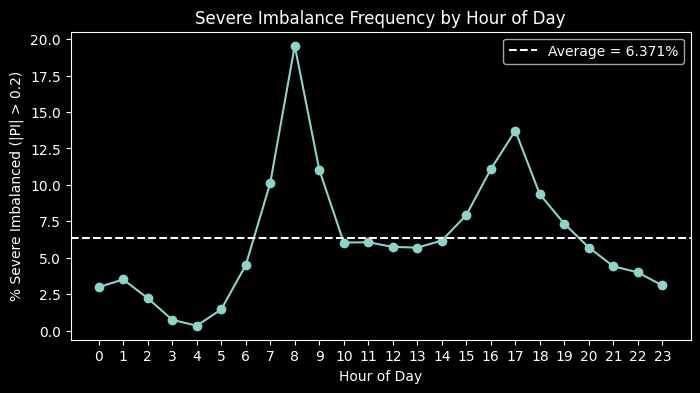

In [4]:
plt.figure(figsize=(8,4))

plt.plot(
    hourly_imbalance["hour_of_day"],
    hourly_imbalance["severe_percent"],
    marker="o",
)

avg_severe = hourly_imbalance["severe_percent"].mean()

plt.axhline(
    y=avg_severe,
    linestyle="--",
    label=f"Average = {avg_severe:.3f}%",
)

plt.xlabel("Hour of Day")
plt.ylabel("% Severe Imbalanced (|PI| > 0.2)")
plt.title("Severe Imbalance Frequency by Hour of Day")

plt.xticks(range(24))
plt.legend()
plt.show()
plt.close()

### Section 2 - Weekday Relationship with Pressure Index
Here, data indicates which day during the week has the highest pressure index as well as the % of stations that has pressure index above 0.2. This is to examine the peak day in a week, setting the foundation for weather analysis.

In [5]:
from src.analyze import analyze_weekday_imbalance

weekday_imbalance = analyze_weekday_imbalance(final_df, severe_threshold=0.2)
weekday_imbalance

,day_of_week,mean_abs_pressure,severe_percent
1,Monday,0.087763,7.445496
5,Tuesday,0.092207,8.957916
6,Wednesday,0.093766,9.346596
4,Thursday,0.091658,8.719836
0,Friday,0.087339,7.410917
2,Saturday,0.085217,7.059256
3,Sunday,0.081580,5.828177


#### Chart 2.1 - Mean Imbalance by Day

As shown in the graph, there are several day that have severe imbalance. The days are:
- Tuesday
- Wednesday
- Thursday

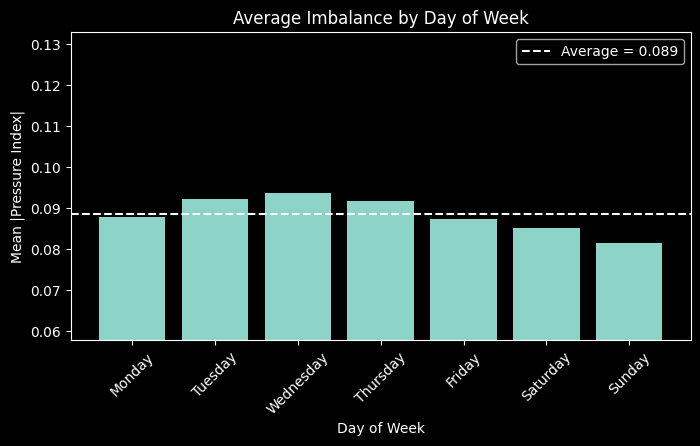

In [6]:
plt.figure(figsize=(8,4))

plt.bar(
    weekday_imbalance["day_of_week"],
    weekday_imbalance["mean_abs_pressure"],
)

avg_value = weekday_imbalance["mean_abs_pressure"].mean()

plt.axhline(
    y=avg_value,
    linestyle="--",
    label=f"Average = {avg_value:.3f}"
)

plt.xlabel("Day of Week")
plt.ylabel("Mean |Pressure Index|")
plt.title("Average Imbalance by Day of Week")
plt.xticks(rotation=45)
plt.legend()

y1_min = hourly_imbalance["mean_abs_pressure"].min()
y1_max = hourly_imbalance["mean_abs_pressure"].max()
plt.ylim(y1_min, y1_max)

plt.show()
plt.close()

#### Chart 2.2 - % of station that are severely imbalanced during the Week
As shown in the graph, several day shows high percentage of sever imbalanced stations count. The hours are:
- Tuesday
- Wednesday
- Thursday

The result are highly correlated with the average absolute pressure index and the % of the imbalanced station during these three days, thereby identifying these three days as the peak days.

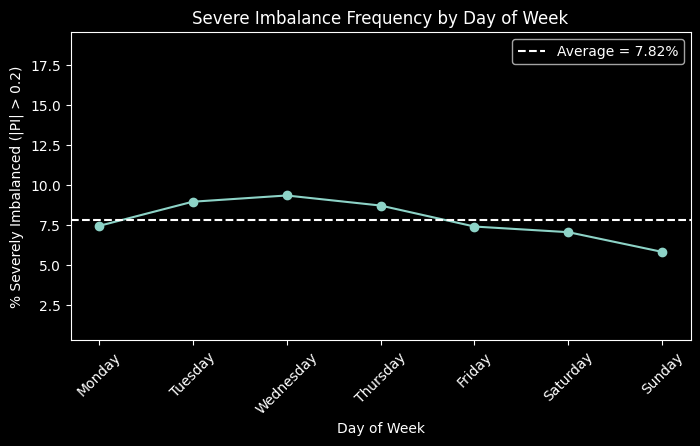

In [7]:
plt.figure(figsize=(8, 4))

plt.plot(
    weekday_imbalance["day_of_week"],
    weekday_imbalance["severe_percent"],
    marker="o"
)

avg_severe = weekday_imbalance["severe_percent"].mean()

plt.axhline(
    y=avg_severe,
    linestyle="--",
    label=f"Average = {avg_severe:.2f}%"
)

plt.xlabel("Day of Week")
plt.ylabel("% Severely Imbalanced (|PI| > 0.2)")
plt.title("Severe Imbalance Frequency by Day of Week")
plt.xticks(rotation=45)
plt.legend()

y2_min = hourly_imbalance["severe_percent"].min()
y2_max = hourly_imbalance["severe_percent"].max()
plt.ylim(y2_min, y2_max)

plt.show()
plt.close()

### Section 3 - Location and Pressure Index Relationship
Identifying which station face the highest imbalance as well as the % of stations that has pressure index above 0.2. This is to examine the peak station, setting the foundation for weather analysis.

In [8]:
from src.analyze import analyze_station_imbalance

station_imbalance = analyze_station_imbalance(final_df, severe_threshold=0.2)
top_station_pressure = station_imbalance.sort_values(
    by = "mean_abs_pressure",
    ascending = False,
).head(10)
top_station_severe = station_imbalance.sort_values(
    by = "severe_percent",
    ascending = False,
).head(10)

print(f"\nTop 10 Station by Average Imbalance")
print(top_station_pressure)

print(f"\nTop 10 Station by Severe Imbalance")
print(top_station_severe)



Top 10 Station by Average Imbalance
    station_id  mean_abs_pressure  severe_percent
417     M32037           0.328657       36.580882
4       A32004           0.243253       33.271719
3       A32003           0.156624       23.062016
2       A32002           0.145234       20.063191
113     B32062           0.141275       19.122257
162     C32036           0.139429       18.666667
160     C32034           0.139246       19.068736
392     M32011           0.138920       27.895595
421     M32041           0.137575       28.164557
441     M32061           0.137495       24.551971

Top 10 Station by Severe Imbalance
    station_id  mean_abs_pressure  severe_percent
417     M32037           0.328657       36.580882
4       A32004           0.243253       33.271719
421     M32041           0.137575       28.164557
392     M32011           0.138920       27.895595
543     T32008           0.127273       25.454545
441     M32061           0.137495       24.551971
399     M32018           0.

#### Section 3.1 - Top Stations by Imbalance

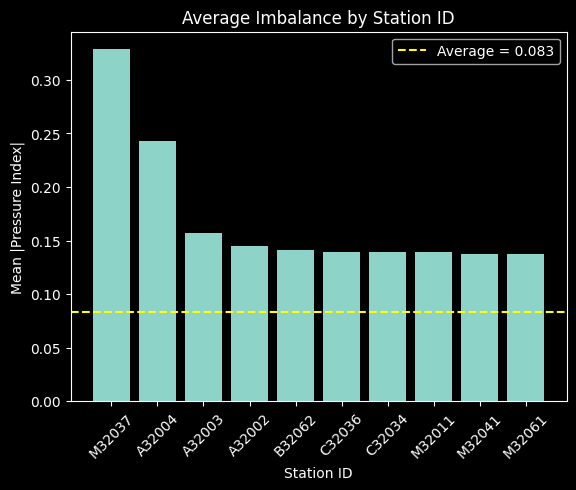

In [47]:
plt.bar(
    top_station_pressure["station_id"],
    top_station_pressure["mean_abs_pressure"],
)

avg_value = station_imbalance["mean_abs_pressure"].mean()

plt.axhline(
    y=avg_value,
    linestyle="--",
    label=f"Average = {avg_value:.3f}",
    color="yellow",
)

plt.xlabel("Station ID")
plt.ylabel("Mean |Pressure Index|")
plt.title("Average Imbalance by Station ID")

plt.xticks(rotation=45)
plt.legend()
plt.show()
plt.close()

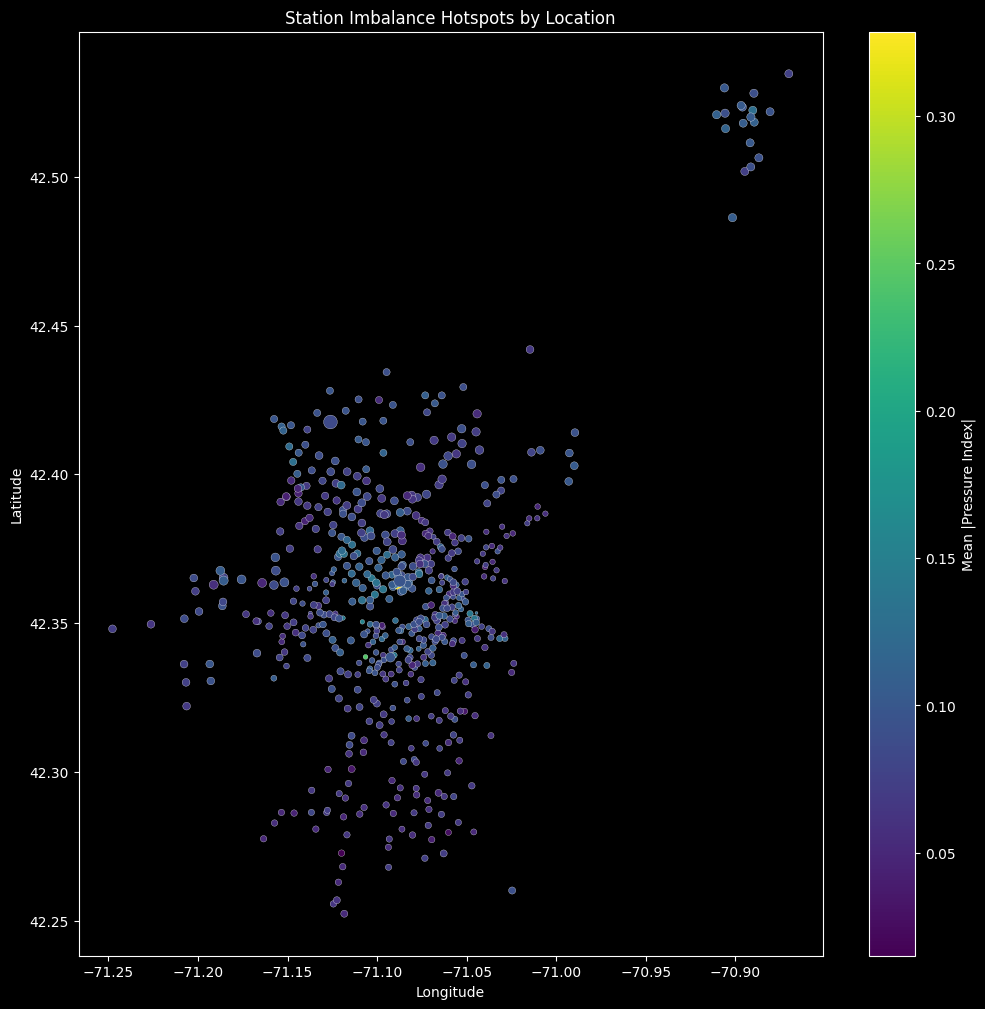

In [48]:
from src.analyze import prepare_station_map_data

station_map_df = prepare_station_map_data(final_df)
station_map_df.head()

plt.figure(figsize=(12,12))

plot_df = station_map_df.sort_values(by = "mean_abs_pressure")
sizes = plot_df["mean_abs_pressure"] * 300

scatter = plt.scatter(
    station_map_df["lon"],
    station_map_df["lat"],
    c = station_map_df["mean_abs_pressure"],
    s = sizes,
    alpha = 1,
    edgecolor = "white",
    linewidth = 0.2,
)

plt.colorbar(scatter, label="Mean |Pressure Index|")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Station Imbalance Hotspots by Location")
plt.show()
plt.close()

### Section 1 & 2 Conclusion:
1. There is **Strong Hourly Pattern** on station pressure. Peak imbalance occur during morning and evening commute hours.
2. There is **Weak Weekly Pattern**, where midweek (Tuesday - Thursday) shows slightly higher imbalance.

These will be factor in the next step, which is the weather analysis.